# ESP Well Failure Prediction — 30-Day Early Warning System
**Project by Regnold Chinowaita and De la Cruz Torres, Diego**

This notebook builds a **Random Forest classifier** to predict Electrical Submersible Pump (ESP)
failures up to **30 days in advance**, using historical sensor and production data.

**Pipeline overview:**
1. Load & cache raw CSV data → pickle
2. Align high-frequency sensor data with daily production data (`structurer`)
3. Downsample to one row per well per day (`frequency_modifier`)
4. Feature engineering — outlier clipping, imputation, ratio features
5. Label engineering — 7-day pre-failure window + 30-day lookahead target
6. Train/test split + SMOTE oversampling to handle class imbalance
7. Train `RandomForestClassifier` and evaluate (classification report, confusion matrix, ROC, feature importance)
8. Deploy on held-out test wells → 30-day failure probability + risk tier dashboard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
plt.rcParams['agg.path.chunksize'] = 10000
%matplotlib inline

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split

import seaborn as sns
import os, glob, pickle, warnings

warnings.filterwarnings('ignore')

plt.rc('font',   size=14)
plt.rc('axes',   labelsize=16, titlesize=16)
plt.rc('legend', fontsize=14)
plt.rc('xtick',  labelsize=14)
plt.rc('ytick',  labelsize=14)

## File Paths

Three paths are defined here and reused throughout:

- **`PATH_TRAIN`** – folder containing all training CSV files (one per well).
- **`PATH_TEST`** – folder containing all test CSV files.
- **`PICKLE_PATH`** – binary cache of the concatenated raw data; loading from pickle is much faster than re-reading all CSVs on every run.

In [2]:
PATH_TRAIN = r"C:\Users\diego\OneDrive - University of Oklahoma\Chinowaita, Regnold's files - e-challenge-prediction-models-for-historical-data-of-esp-patterns-main\Group 2 DA Project\e-challenge\Data\Historical Data of ESP Patterns\Train"
PATH_TEST  = r"C:\Users\diego\OneDrive - University of Oklahoma\Chinowaita, Regnold's files - e-challenge-prediction-models-for-historical-data-of-esp-patterns-main\Group 2 DA Project\e-challenge\Data\Historical Data of ESP Patterns\Test"

PICKLE_PATH = r"C:\Users\diego\OneDrive - University of Oklahoma\Chinowaita, Regnold's files - e-challenge-prediction-models-for-historical-data-of-esp-patterns-main\Group 2 DA Project\Clean\datos_processed.pkl"

##  Helper — `concat_data`

Reads a list of CSV file paths and stacks them into a single `DataFrame` (vertical concat).
Column index `1` is parsed as a date directly during `read_csv` to avoid a separate conversion step.

In [3]:
def concat_data(files):
    dataframes = []
    for i in range(len(files)):
        df = pd.read_csv(files[i], parse_dates=[1])
        dataframes.append(df)
    return pd.concat(dataframes, axis=0).reset_index(drop=True)

##  Load or Build the Raw Dataset

**Cache logic:** if the pickle exists, load the four DataFrames instantly.
Otherwise, scan each folder for `*.csv` files, sort alphabetically (the last file is always the production/ground-truth file), concatenate the rest with `concat_data`, sort by `DATE`, and write everything to the pickle.



In [4]:
if os.path.exists(PICKLE_PATH):
    with open(PICKLE_PATH, 'rb') as f:
        train, test, production_train, production_test = pickle.load(f)
    print("data loaded from pickle")

else:
    train_dirs = glob.glob(PATH_TRAIN + '/*.csv')
    train_dirs.sort()
    test_dirs  = glob.glob(PATH_TEST  + '/*.csv')
    test_dirs.sort()

    train            = concat_data(train_dirs[:-1])
    train            = train.sort_values(by=['DATE']).reset_index(drop=True)

    test             = concat_data(test_dirs[:-1])
    test             = test.sort_values(by=['DATE']).reset_index(drop=True)

    production_train = pd.read_csv(train_dirs[-1], parse_dates=[1])
    production_train = production_train.sort_values(by=['DATE']).reset_index(drop=True)

    production_test  = pd.read_csv(test_dirs[-1], parse_dates=[1])
    production_test  = production_test.sort_values(by=['DATE']).reset_index(drop=True)

    with open(PICKLE_PATH, 'wb') as f:
        pickle.dump((train, test, production_train, production_test), f)
    print("Pickle date saved")

Pickle date saved


##  Date Standardisation

Convert all four `DATE` columns from mixed string formats to `datetime64`.
`format='mixed'` handles both `DD/MM/YYYY` and `YYYY-MM-DD`; `dayfirst=True` resolves ambiguous dates like `01/02/2022` as 1 February.

In [5]:
train['DATE']            = pd.to_datetime(train['DATE'], format='mixed', dayfirst=True)
test['DATE']             = pd.to_datetime(test['DATE'], format='mixed', dayfirst=True)
production_train['DATE'] = pd.to_datetime(production_train['DATE'], format='mixed', dayfirst=True)
production_test['DATE']  = pd.to_datetime(production_test['DATE'], format='mixed', dayfirst=True)

print("Date to Datetime conversion")

Date to Datetime conversion


## Column Deduplication — `PRESS_INT` / `TEMP_INT`

Some CSV files store the same measurement under two column names (`PRESS_INT` vs `PRESS_INTK`, `TEMP_INT` vs `TEMP_INTK`).
We fill nulls in the primary column from the alternative, then drop the redundant columns.

In [6]:
train['PRESS_INT'] = train['PRESS_INT'].fillna(train['PRESS_INTK'])
train['TEMP_INT']  = train['TEMP_INT'].fillna(train['TEMP_INTK'])
test['PRESS_INT']  = test['PRESS_INT'].fillna(test['PRESS_INTK'])
test['TEMP_INT']   = test['TEMP_INT'].fillna(test['TEMP_INTK'])

del train['PRESS_INTK']
del train['TEMP_INTK']
del test['PRESS_INTK']
del test['TEMP_INTK']

##  Well Inventory Check

Confirm the number of unique wells in each split before proceeding.
The training set drives model fitting; the test set is held out entirely for final evaluation.

In [7]:
train_wells = train['WELL_ID'].unique()
test_wells  = test['WELL_ID'].unique()

print('Train wells: ', len(train_wells))
print('Test wells: ',  len(test_wells))

Train wells:  100
Test wells:  15


## `structurer` — Aligning Sensor Data with Daily Production Data

The two data sources have different temporal resolutions (intra-day sensor readings vs. once-per-day production reports), so a simple `merge` on `DATE` loses rows.

`structurer` solves this per well:
1. **Filters** production rows to years ≥ 2019 and removes duplicate dates where `PIP(PSI)` is null.
2. **Resamples** the production series to a strict daily cadence (`asfreq('d')`) and forward-fills gaps.
3. **Matches** each production day to the closest sensor snapshot within ±1 day, broadcasting production values onto every sensor row for that day.
4. **Returns** a single merged DataFrame — one row per sensor reading, enriched with daily production KPIs.

In [8]:
def structurer(wells, production_data, high_freq_data):

    df = []

    for well in wells:
        try:
            pump = production_data[production_data['WELL_ID'] == well]
            pump = pump[pump['DATE'].dt.year >= 2019].sort_values(by=['DATE'])
            duplicated = pump[pump['DATE'].duplicated(keep=False)]
            idx_2ptd   = duplicated[duplicated['PIP(PSI)'].isnull()].index
            pump       = pump.drop(index=idx_2ptd).reset_index().drop(columns='index')
            pump       = pump.set_index('DATE').asfreq('d').ffill().reset_index()
            pump['DATE'] = pd.to_datetime(pump['DATE']).dt.normalize()

            sensor = high_freq_data[high_freq_data['WELL_ID'] == well]
            sensor = sensor.drop_duplicates().reset_index().drop(columns='index')
            sensor['DATE'] = pd.to_datetime(sensor['DATE']).dt.normalize()

            sensor_dates = sensor['DATE'].unique()
            pump_dates   = pump['DATE'].unique()

            merged = []

            for _ in pump_dates:

                if _ in sensor_dates:
                    shot   = sensor[sensor['DATE'] == _].reset_index().drop(columns='index')
                    bullet = pump[pump['DATE'] == _].reset_index().drop(columns='index')

                    for i in bullet.keys().drop(['WELL_ID', 'DATE']):
                        shot[i] = bullet.loc[0, i]
                    merged.append(shot)

                else:
                    time        = pd.Timestamp(_)
                    year, month = time.year, time.month
                    sun         = sensor[sensor['DATE'].dt.year == year]
                    moon        = sun[sun['DATE'].dt.month == month].reset_index().drop(columns='index')
                    bullet      = pump[pump['DATE'] == _].reset_index().drop(columns='index')

                    if len(moon) != 0:
                        closest = min(list(moon['DATE']), key=lambda sub: abs(sub - time))

                        if abs((closest - time).days) <= 1:
                            moon = moon[moon['DATE'] == closest].reset_index().drop(columns='index')
                            for i in bullet.keys().drop(['WELL_ID', 'DATE']):
                                moon[i] = bullet.loc[0, i]
                            merged.append(moon)

            if len(merged) > 0:
                merged = pd.concat(merged, axis=0).reset_index().drop(columns='index')
                merged = merged.drop_duplicates(subset='DATE', keep='last')
                df.append(merged)
            else:
                print(f'No data for well: {well}')

        except Exception as e:
            print(f'Error in well {well}: {e}')

    return pd.concat(df, axis=0).reset_index().drop(columns='index')

## Run `structurer` on Both Splits

Calling `structurer` once for training wells and once for test wells.
Shapes are printed to verify the merge produced a sensible number of rows.

In [9]:
structured_train = structurer(train_wells, production_train, train)
structured_test  = structurer(test_wells,  production_test,  test)

print('Train shape: ', structured_train.shape)
print('Test shape: ',  structured_test.shape)

No data for well: DEEPWATER-1WHBG2
No data for well: DEEPWATER-BZZIEL
No data for well: DEEPWATER-MIVF4C
Train shape:  (48345, 25)
Test shape:  (7889, 25)


##  Remove Untagged Wells

Three training wells have no failure labels and are useless for supervised learning.
We drop all their rows and confirm the training set now contains 94 labelled wells.

In [10]:
to_remove = ['DEEPWATER-55X0XE', 'DEEPWATER-D4EH50', 'DEEPWATER-ZISKRZ']
idxs = []

for i in to_remove:
    idx = structured_train[structured_train['WELL_ID'] == i].index
    idxs.append(idx)

structured_train = structured_train.drop(np.hstack(idxs)).reset_index().drop(columns='index')
print('Wells in train after cleaning: ', len(structured_train['WELL_ID'].unique()))

Wells in train after cleaning:  94


##  Save Structured Data to Pickle

Serialise `structured_train` and `structured_test` so the expensive `structurer` loop can be skipped on re-runs.

In [11]:
PICKLE_STRUCTURED =r"C:\Users\diego\OneDrive - University of Oklahoma\Chinowaita, Regnold's files - e-challenge-prediction-models-for-historical-data-of-esp-patterns-main\Group 2 DA Project\Clean\datos_structure.pkl"

with open(PICKLE_STRUCTURED, 'wb') as f:
    pickle.dump((structured_train, structured_test), f)

print("Structured data saved in pickle")

Structured data saved in pickle


##  `frequency_modifier` — Downsampling to One Row Per Well Per Day

The merged data still has multiple sensor readings per well per day.
`frequency_modifier` converts this to a daily cadence:

- **`average_features`** – replaces all numeric values on a given day with their daily mean.
- **`change`** – resamples each well to strict daily frequency (`asfreq('D')`), forward-fills gaps, and re-maps failure event labels to the correct date row.

In [12]:
class frequency_modifier:

    def __init__(self, data):
        self.data = data

    def wells(self):
        return self.data['WELL_ID'].unique()

    def average_features(self):
        wells_ = self.wells()
        mean_df = []

        for well in wells_:
            df = self.data[self.data['WELL_ID'] == well].reset_index().drop(columns='index')
            dates = list(df['DATE'].dt.normalize().unique())

            for _ in dates:
                time = pd.Timestamp(_)
                day  = df[df['DATE'].dt.date == time.date()]
                averages = dict(zip(day.mean(numeric_only=True).index,
                                    day.mean(numeric_only=True)))

                for key in df.keys().drop(['PUMP', 'WELL_ID', 'DATE', 'WellFailure']):
                    if key in averages:
                        df.loc[day.index, key] = averages[key]

            mean_df.append(df)

        return pd.concat(mean_df, axis=0).sort_values(['WELL_ID', 'DATE']).reset_index().drop(columns='index')

    def change(self):
        wells_   = self.wells()
        mean_df  = self.average_features()

        dates       = self.data[self.data['WellFailure'].notnull()].groupby('WELL_ID')['DATE'].unique()
        event_types = self.data[self.data['WellFailure'].notnull()].groupby('WELL_ID')['WellFailure'].unique()

        daily = []

        if len(dates) != 0:
            for i in range(len(dates)):
                df = mean_df[mean_df['WELL_ID'] == np.sort(wells_)[i]].reset_index().drop(columns='index')
                df = df.set_index('DATE').asfreq('D').ffill()
                df['WellFailure'] = np.nan

                date  = dates.iloc[i]
                event = list(event_types.iloc[i])

                if len(date) != len(event):
                    event.append(event[0])

                df = df.reset_index()
                df['DATE'] = df['DATE'].astype('datetime64[ns]')

                for _ in range(len(date)):
                    moment = pd.Timestamp(date[_])
                    idx    = df[df['DATE'].dt.normalize() == moment.normalize()].index
                    if len(idx) > 0:
                        df.loc[idx[0], 'WellFailure'] = event[_]

                daily.append(df)

            return pd.concat(daily, axis=0)

        else:
            for i in range(len(wells_)):
                df = mean_df[mean_df['WELL_ID'] == np.sort(wells_)[i]]
                df = df.set_index('DATE').asfreq('D').ffill()
                daily.append(df)
            return pd.concat(daily, axis=0).reset_index()

##  Run `frequency_modifier` on Both Splits

The result is one row per well per day — ready for feature engineering and modelling.

In [13]:
daily_train = frequency_modifier(structured_train).change()
daily_test  = frequency_modifier(structured_test).change()

print('Daily Train shape: ', daily_train.shape)
print('Daily Test shape: ',  daily_test.shape)

Daily Train shape:  (20848, 25)
Daily Test shape:  (9790, 25)


## Save Daily Data to Pickle

Cache the daily DataFrames so the slow resampling step can be skipped on re-runs.

In [14]:
PICKLE_DAILY = r"C:\Users\diego\OneDrive - University of Oklahoma\Chinowaita, Regnold's files - e-challenge-prediction-models-for-historical-data-of-esp-patterns-main\Group 2 DA Project\Clean\datos_daily.pkl"

with open(PICKLE_DAILY, 'wb') as f:
    pickle.dump((daily_train, daily_test), f)

print("Daily data saved in pickle")

Daily data saved in pickle


## Concatenate Splits & Encode Target

Stack `daily_train` and `daily_test` into a single `data` DataFrame, recording the index ranges that separate them.
Global feature engineering is applied once, then each split is sliced back out later.
Two columns are also renamed for clarity: `PROF_INTAKE → INTAKE_DEPTH`, `PSI_CAB → WHP(PSI)`.

In [15]:
data = pd.concat([daily_train, daily_test], axis=0).reset_index().drop(columns='index')
data['DATE'] = data['DATE'].dt.normalize()

train_index = np.arange(0, len(daily_train))
test_index  = np.arange(len(daily_train), len(daily_train) + len(daily_test))

nums      = np.arange(1, len(data['WELL_ID'].unique()) + 1)
data_dict = dict(zip(data['WELL_ID'].unique(), nums))

data['WELL_ID'] = data['WELL_ID'].replace(data_dict)
data['FAILURE'] = data['WellFailure'].replace({np.nan: 0, 'yes': 1, 'Manual off': 2})
data            = data.rename(columns={'PROF_INTAKE': 'INTAKE_DEPTH', 'PSI_CAB': 'WHP(PSI)'})

print('Data shape: ', data.shape)
print('Class distribution:')
print(data['FAILURE'].value_counts())

Data shape:  (30638, 26)
Class distribution:
FAILURE
0    30612
1       23
2        3
Name: count, dtype: int64


## Outlier Clipping

Sensor readings can contain physically impossible values from instrument faults or logging errors.
`outlier_replacer` clips each column to a domain-knowledge-based `[min, max]` range (Winsorisation).


In [16]:
def outlier_replacer(df, column, min=None, max=None):
    if min is not None:
        df.loc[df[column] <= min, column] = min
    if max is not None:
        df.loc[df[column] >= max, column] = max
    return df

outlier_replacer(data, 'PRESS_DESC',      min=0,     max=10500)
outlier_replacer(data, 'CURRENT',         min=20,    max=150)
outlier_replacer(data, 'PRESS_INT',       min=0,     max=5000)
outlier_replacer(data, 'FREQUENCY',       min=25,    max=150)
outlier_replacer(data, 'VIBRATION',       min=0,     max=20)
outlier_replacer(data, 'TEMP_MOT',        min=175,   max=500)
outlier_replacer(data, 'BWPD',           min=0,     max=None)
outlier_replacer(data, 'WHP(PSI)',        min=0,     max=400)
outlier_replacer(data, 'INTAKE_DEPTH',    min=8000,  max=None)

print("Outliers treated")

Outliers treated


##  Missing Value Imputation

**Stage 1 — Column bridging:** some sensors report the same measurement under two column names (legacy vs. current instrumentation).
Nulls in `PRESS_INT`, `CURRENT`, and `FREQUENCY` are filled from their duplicate columns.

**Stage 2 — Median fill:** remaining nulls in `TEMP_INT`, `TEMP_MOT`, `PRESS_DESC`, `VIBRATION`, and `OUT_VOLT` are replaced with each column's median — robust against the skewed sensor distributions.

In [17]:
# Stage 1: column bridging — fill primary sensors from their duplicate columns
data['PRESS_INT'] = data['PRESS_INT'].fillna(data['PIP(PSI)'])
data['CURRENT']   = data['CURRENT'].fillna(data['AMPERAGE'])
data['FREQUENCY'] = data['FREQUENCY'].fillna(data['FREC(Hz)'])

# Stage 2: median fill for sensors with no duplicate column
cols_to_impute = ['TEMP_INT', 'TEMP_MOT', 'PRESS_DESC', 'VIBRATION', 'OUT_VOLT']
for col in cols_to_impute:
    data[col] = data[col].fillna(data[col].median())

# Stage 3: fill any remaining numeric nulls (e.g. PIP(PSI), AMPERAGE, FREC(Hz))
# using per-well forward-fill first, then global median as fallback
numeric_cols = data.select_dtypes(include='number').columns
data[numeric_cols] = (
    data.groupby('WELL_ID')[numeric_cols]
    .transform(lambda x: x.ffill().bfill())
)
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

print("Imputation completed")
remaining = data.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print("No remaining missing values ✓")
else:
    print("Remaining missing values:")
    print(remaining)

Imputation completed
Remaining missing values:
WellFailure    30612
dtype: int64


##  Training Slice & Ratio Feature Engineering

We slice out the training portion of `data` into `data_rf` and add three engineered features:

BFPD/FREQ*60` 
BOPD/FREQ*60` 
PRESS_RATIO` 

Dividing by frequency removes the pump-speed effect, exposing true efficiency changes.
Adding `1e-9` to denominators prevents division-by-zero.

In [18]:
data_rf = data.loc[train_index].copy()

data_rf['BFPD/FREQ*60'] = data_rf['BFPD'] / (data_rf['FREQUENCY'] + 1e-9) * 60
data_rf['BOPD/FREQ*60'] = data_rf['BOPD'] / (data_rf['FREQUENCY'] + 1e-9) * 60
data_rf['PRESS_RATIO']  = data_rf['PRESS_INT'] / (data_rf['PRESS_DESC'] + 1e-9)

print("Ratio features created: BFPD/FREQ*60, BOPD/FREQ*60, PRESS_RATIO")

Ratio features created: BFPD/FREQ*60, BOPD/FREQ*60, PRESS_RATIO


## Pre-Failure Window Labelling

A pump deteriorates gradually before it fails outright.
For each confirmed failure event, the **7 days immediately before** the failure date are labelled `FAILURE = 1`.
This teaches the model to recognise the degradation signature, not just the final breakdown moment.

In [ ]:
for well_id in data_rf['WELL_ID'].unique():
    well_data  = data_rf[data_rf['WELL_ID'] == well_id]
    fail_dates = well_data[well_data['FAILURE'] == 1].index  # Only 'yes', no Manual Off

    for idx in fail_dates:
        pos   = data_rf.index.get_loc(idx)
        start = max(0, pos - 7)
        data_rf.iloc[start:pos, data_rf.columns.get_loc('FAILURE')] = 1

##  Binary Target & 30-Day Lookahead

**Binary encoding:** `Manual off` rows (class 2) represent planned shutdowns — they look nothing like failures, so we drop them and collapse the labels to binary (0 = normal, 1 = failure/pre-failure).

**30-day lookahead (`FAILURE_30D`):** instead of asking *"is the pump failing today?"*, we ask *"will it fail in the next 30 days?"*.
A 30-day forward-rolling maximum over `FAILURE` sets today's label to 1 if any failure occurs in the coming 30 days — giving operators **actionable lead time**.

In [20]:
data_rf = data_rf[data_rf['FAILURE'] != 2].copy()
data_rf['FAILURE'] = data_rf['FAILURE'].apply(lambda x: 0 if x == 0 else 1)

print("Final Distribution:")
print(data_rf['FAILURE'].value_counts())

# Feature list
features_rf = [
    'CURRENT', 'PRESS_DESC', 'FREQUENCY', 'PRESS_INT',
    'TEMP_INT', 'TEMP_MOT', 'OUT_VOLT', 'VIBRATION',
    'BWPD', 'INTAKE_DEPTH',
    'BFPD/FREQ*60', 'BOPD/FREQ*60', 'PRESS_RATIO'
]

# 30-day lookahead target
data_rf = data_rf.sort_values(['WELL_ID', 'DATE']).reset_index(drop=True)

data_rf['FAILURE_30D'] = (
    data_rf.groupby('WELL_ID')['FAILURE']
    .transform(lambda x: x.rolling(window=30, min_periods=1)
                          .max()
                          .shift(-30)
                          .fillna(0))
    .astype(int)
)

print(f"\n30-Day target distribution:")
print(data_rf['FAILURE_30D'].value_counts())
print(f"\nOriginal failure days : {data_rf['FAILURE'].sum()}")
print(f"30-day warning days   : {data_rf['FAILURE_30D'].sum()}")

X = data_rf[features_rf]
y = data_rf['FAILURE_30D']

Final Distribution:
FAILURE
0    20661
1      184
Name: count, dtype: int64

30-Day target distribution:
FAILURE_30D
0    20070
1      775
Name: count, dtype: int64

Original failure days : 184
30-day warning days   : 775


## Train/Test Split & SMOTE Oversampling

**Split:** 80 % training / 20 % test, stratified to preserve the failure rate in both halves.

**SMOTE (Synthetic Minority Over-sampling Technique):** failure events represent ~0.2 % of rows.
SMOTE generates synthetic minority-class examples by interpolating between real failure neighbours in feature space, balancing the training set without simply duplicating rows.
This dramatically improves recall on the failure class.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Show class counts BEFORE SMOTE (professor recommendation)
print("Class counts BEFORE SMOTE:")
before = pd.Series(y_train).value_counts().sort_index()
print(f"  Normal (0) : {before.get(0, 0)}")
print(f"  Failure (1): {before.get(1, 0)}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Show class counts AFTER SMOTE
print("\nClass counts AFTER SMOTE:")
after = pd.Series(y_train_bal).value_counts().sort_index()
print(f"  Normal (0) : {after.get(0, 0)}")
print(f"  Failure (1): {after.get(1, 0)}")
print(f"\nSMOTE added {after.get(1,0) - before.get(1,0)} synthetic failure samples")

Class counts BEFORE SMOTE:
  Normal (0) : 16056
  Failure (1): 620

Class counts AFTER SMOTE:
  Normal (0) : 16056
  Failure (1): 16056

SMOTE added 15436 synthetic failure samples


##  Flow Rate vs Time — Colored by Operating Frequency

Two-panel diagnostic chart to visualise ESP pump performance across all wells:

Each point is colored by the pump's **integer Hz operating frequency** using a rainbow palette, with a discrete per-Hz legend at the top.
Red × markers flag confirmed failure events.


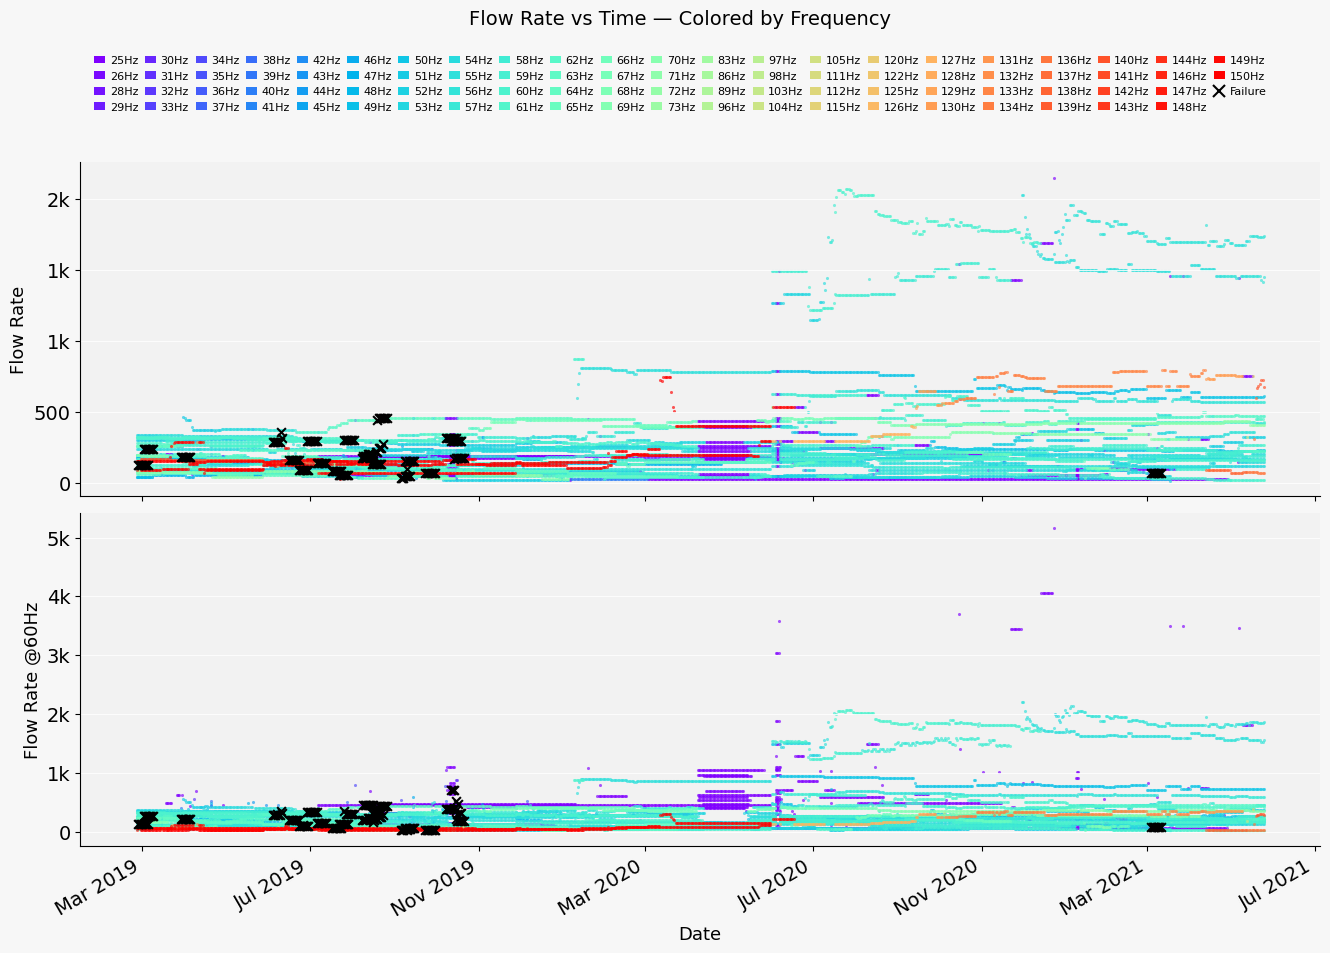

In [46]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(16, 9),
    sharex=True,
    gridspec_kw={'hspace': 0.05}
)
fig.patch.set_facecolor('#f7f7f7')
for ax in (ax1, ax2):
    ax.set_facecolor('#f2f2f2')

# Discrete colour mapping by rounded Hz
data_rf['FREQ_INT'] = data_rf['FREQUENCY'].round().astype(int)
hz_values = sorted(data_rf['FREQ_INT'].unique())

cmap_base = plt.cm.get_cmap('rainbow', len(hz_values))
hz_color  = {hz: cmap_base(i / max(len(hz_values) - 1, 1))
             for i, hz in enumerate(hz_values)}

# Plot every well, scatter by Hz group
for hz in hz_values:
    subset = data_rf[data_rf['FREQ_INT'] == hz].sort_values('DATE')
    c = hz_color[hz]
    ax1.scatter(subset['DATE'], subset['BOPD'],
                c=[c], s=5, alpha=0.65, linewidths=0, rasterized=True)
    ax2.scatter(subset['DATE'], subset['BOPD/FREQ*60'],
                c=[c], s=5, alpha=0.65, linewidths=0, rasterized=True)

# Failure markers
failures = data_rf[data_rf['FAILURE'] == 1]
ax1.scatter(failures['DATE'], failures['BOPD'],
            c='black', s=40, marker='x', linewidths=1.5, zorder=6)
ax2.scatter(failures['DATE'], failures['BOPD/FREQ*60'],
            c='black', s=40, marker='x', linewidths=1.5, zorder=6)

# Axes formatting
ax1.set_ylabel('Flow Rate', fontsize=13)
ax2.set_ylabel('Flow Rate @60Hz', fontsize=13)
ax2.set_xlabel('Date', fontsize=13)

ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x)))
)
ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x)))
)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')

for ax in (ax1, ax2):
    ax.grid(axis='y', color='white', linewidth=0.6)
    ax.spines[['top', 'right']].set_visible(False)

# Discrete Hz legend at the top of the figure
legend_handles = [
    Patch(facecolor=hz_color[hz], edgecolor='none', label=f'{hz}Hz')
    for hz in hz_values
]
legend_handles.append(
    Line2D([0], [0], marker='x', color='black', lw=0,
           markersize=8, markeredgewidth=1.5, label='Failure')
)

fig.legend(
    handles=legend_handles,
    loc='upper center',
    ncol=min(len(hz_values) + 1, 22),
    fontsize=8,
    frameon=False,
    bbox_to_anchor=(0.5, 1.01),
    handlelength=1.0,
    handletextpad=0.4,
    columnspacing=0.6
)

fig.subplots_adjust(bottom=0.12)
fig.suptitle('Flow Rate vs Time — Colored by Frequency', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

##  Random Forest — Training & Classification Report

The `RandomForestClassifier` is trained on the SMOTE-balanced data with:
- **200 trees** for stable probability estimates.
- **Max depth 15** to balance expressiveness and overfitting resistance.
- **`class_weight='balanced'`** as an additional safeguard against class imbalance.

The classification report evaluates precision, recall, and F1 on the held-out 20 % test split.

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train_bal, y_train_bal)
y_pred = rf_model.predict(X_test)

print("\n── Results ───────────────────────")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Failure']))


── Results ───────────────────────
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      4014
     Failure       0.64      0.91      0.75       155

    accuracy                           0.98      4169
   macro avg       0.82      0.95      0.87      4169
weighted avg       0.98      0.98      0.98      4169



##  Confusion Matrix



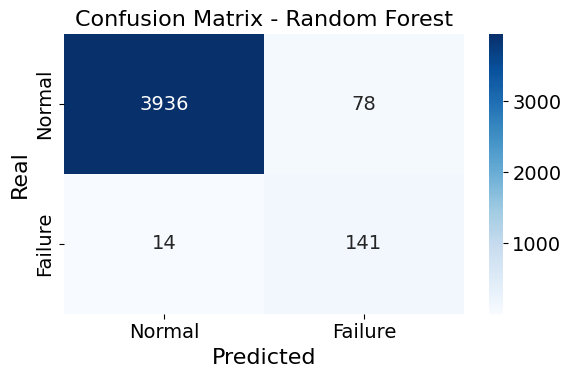

In [24]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Real')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

##  Feature Importance

Random Forests measure each feature's contribution via mean decrease in impurity.
Higher importance = the model relied on that sensor more to separate failures from normal operation.
This ranking guides sensor prioritisation for real-time monitoring dashboards.

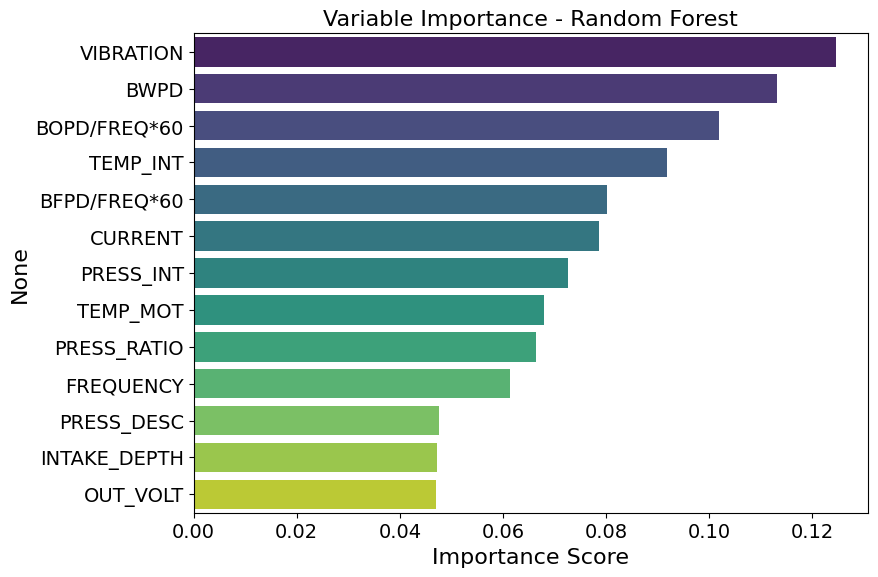


Top 5 most important variables:
VIBRATION       0.124544
BWPD            0.113093
BOPD/FREQ*60    0.101807
TEMP_INT        0.091769
BFPD/FREQ*60    0.080253
dtype: float64


In [25]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=features_rf
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Variable Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important variables:")
print(importances.head())

## ROC Curve

Plots True Positive Rate vs. False Positive Rate at every classification threshold.
**AUC** summarises discrimination power: 1.0 = perfect, 0.5 = random.
For imbalanced datasets like ours, AUC is more informative than raw accuracy.

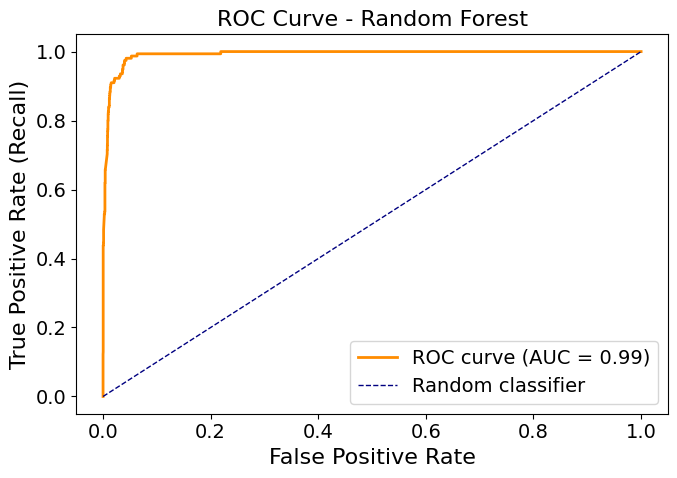

AUC Score: 0.992
→ A high AUC (close to 1.0) indicates that the model effectively distinguishes between failures and normal conditions.


In [26]:
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.3f}")
print("→ A high AUC (close to 1.0) indicates that the model effectively distinguishes between failures and normal conditions.")

## Sensor Behaviour in the 30 Days Before a Real Failure

We select one confirmed failure event and plot each key sensor's trend over the 30 days leading up to it.
This is a visual sanity check: are the features the model finds important actually showing measurable degradation before failure?

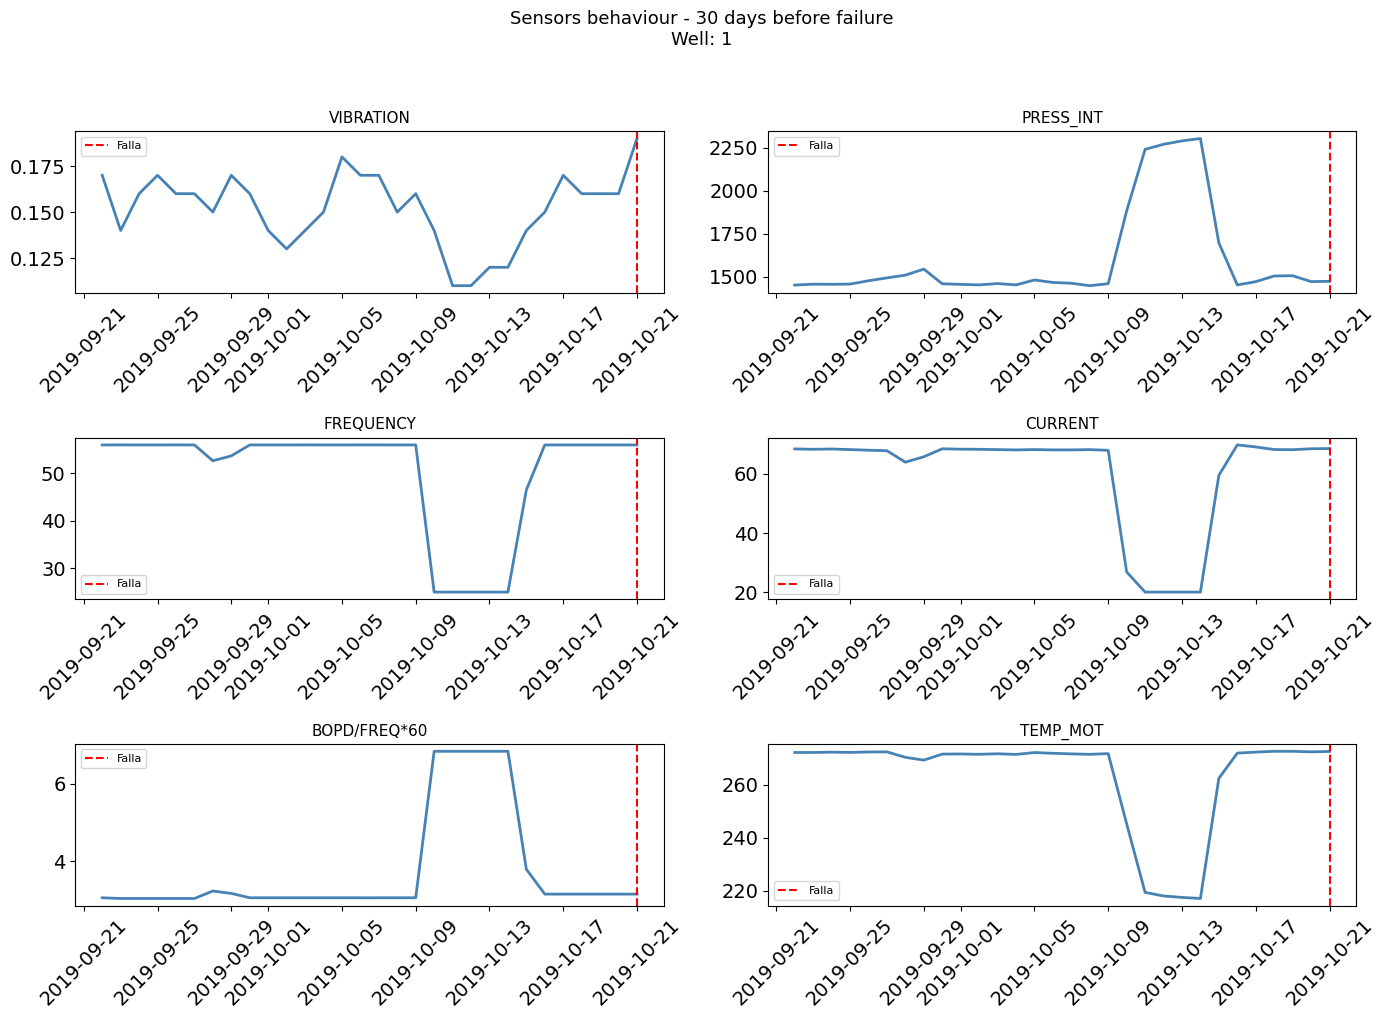

In [27]:
failure_data   = data[data['FAILURE'] == 1].iloc[0]
well_failure   = failure_data['WELL_ID']
date_failure  = data[data['FAILURE'] == 1][data['WELL_ID'] == well_failure]['DATE'].iloc[0]

well_df      = data[data['WELL_ID'] == well_failure].copy()
well_df      = well_df.sort_values('DATE').set_index('DATE')
window      = well_df[well_df.index <= date_failure].tail(30)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.ravel()

sensors = ['VIBRATION', 'PRESS_INT', 'FREQUENCY', 'CURRENT', 'BOPD/FREQ*60', 'TEMP_MOT']

window['BOPD/FREQ*60'] = window['BOPD'] / (window['FREQUENCY'] + 1e-9)

for ax, sensor in zip(axes, sensors):
    ax.plot(window.index, window[sensor], color='steelblue', linewidth=2)
    ax.axvline(x=date_failure, color='red', linestyle='--', linewidth=1.5, label='Falla')
    ax.set_title(sensor, fontsize=11)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=8)

plt.suptitle(f'Sensors behaviour - 30 days before failure\nWell: {well_failure}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

##  Summary Statistics — Normal Operation vs. Pre-Failure Window

Compare the mean of each key feature between normal rows and the 7-day window before failure.
A clear statistical difference confirms the feature carries predictive signal.

In [28]:
data['BOPD/FREQ*60'] = data['BOPD'] / (data['FREQUENCY'] + 1e-9) * 60
data['BFPD/FREQ*60'] = data['BFPD'] / (data['FREQUENCY'] + 1e-9) * 60
data['PRESS_RATIO']    = data['PRESS_INT'] / (data['PRESS_DESC'] + 1e-9)

cols_summary = ['VIBRATION', 'PRESS_INT', 'FREQUENCY', 'CURRENT', 'BOPD/FREQ*60']
well_failure  = data[data['FAILURE'] == 1]['WELL_ID'].unique()
global_avg   = data[data['FAILURE'] == 0][cols_summary].mean()

summary = []

for well in well_failure:
    well_df     = data[data['WELL_ID'] == well].sort_values('DATE')
    date_fail = well_df[well_df['FAILURE'] == 1]['DATE'].iloc[0]
    window     = well_df[well_df['DATE'] <= date_fail].tail(7)

    row = {'WELL_ID': str(well)}
    for col in cols_summary:
        if col in window.columns:
            row[col] = round(float(window[col].mean()), 2)
    summary.append(row)

normal_row = {'WELL_ID': 'Normal Average'}
for col in cols_summary:
    normal_row[col] = round(float(global_avg[col]), 2)
summary.append(normal_row)

summary_df = pd.DataFrame(summary).set_index('WELL_ID')

print("── Summary table: normal vs failure ──")
print(summary_df.to_string())

── Summary table: normal vs failure ──
                VIBRATION  PRESS_INT  FREQUENCY  CURRENT  BOPD/FREQ*60
WELL_ID                                                               
1                    0.16    1510.14      54.58    67.45        194.62
3                    0.25     226.67      57.34    21.00        148.60
4                    0.10    2079.40      52.50    20.00        340.80
7                    0.16    2245.42      25.00    20.00        144.00
8                    0.11    3850.68      25.00    20.00        457.92
11                   0.78     394.79      59.76    25.90        303.95
12                   0.20     189.66      59.00    20.00        132.53
13                   0.00       0.00      52.50    29.05        222.96
14                   0.00       0.00      63.00    31.75         44.42
15                   0.16    2174.03      49.00    29.41        224.82
16                   0.25     953.16      63.55    29.88        433.55
17                   0.00     248.71  

##  30-Day Predictive Maintenance on Test Wells

The trained model is applied to the 15 held-out test wells to simulate real deployment.

For each well we compute:
1. **`P_30_days(%)`** — cumulative probability of at least one failure in the next 30 days: `P₃₀ = 1 − (1 − P_avg)³⁰`.
2. **`sustained_alert_days`** — days where the 5-day rolling average probability exceeds 50 %, filtering out isolated spikes caused by noisy sensor readings.
3. **`RISK_TIER`** — traffic-light classification combining both metrics.

In [29]:
data_test = data.loc[test_index].copy()

data_test['BOPD/FREQ*60'] = data_test['BOPD'] / (data_test['FREQUENCY'] + 1e-9) * 60
data_test['BFPD/FREQ*60'] = data_test['BFPD'] / (data_test['FREQUENCY'] + 1e-9) * 60
data_test['PRESS_RATIO']  = data_test['PRESS_INT'] / (data_test['PRESS_DESC'] + 1e-9)

X_test_original = data_test[features_rf]
y_pred_test     = rf_model.predict(X_test_original)
y_prob_test     = rf_model.predict_proba(X_test_original)[:, 1]

data_test['PRED_FAILURE'] = y_pred_test
data_test['PROB_FAILURE'] = y_prob_test.round(3)

resumen_test = data_test.groupby('WELL_ID').agg(
    total_days        = ('PRED_FAILURE', 'count'),
    days_with_failure = ('PRED_FAILURE', 'sum'),
    max_failure_prob  = ('PROB_FAILURE', 'max'),
    avg_failure_prob  = ('PROB_FAILURE', 'mean')
).round(3)

resumen_test['% days in alert'] = (
    resumen_test['days_with_failure'] / resumen_test['total_days'] * 100
).round(1)

# Cumulative 30-day probability: P_30 = 1 - (1 - P_avg)^30
resumen_test['P_30_days(%)'] = (
    (1 - (1 - resumen_test['avg_failure_prob']) ** 30) * 100
).round(1)

# Sustained alert days: 5-day rolling average > 50%
sustained = []
for well_id in data_test['WELL_ID'].unique():
    well_df = data_test[data_test['WELL_ID'] == well_id].sort_values('DATE').copy()
    well_df['PROB_ROLLING_5D'] = well_df['PROB_FAILURE'].rolling(window=5, min_periods=1).mean()
    sustained.append({
        'WELL_ID':              well_id,
        'max_sustained_prob':   round(well_df['PROB_ROLLING_5D'].max(), 3),
        'sustained_alert_days': int((well_df['PROB_ROLLING_5D'] > 0.5).sum())
    })

sustained_df = pd.DataFrame(sustained).set_index('WELL_ID')
resumen_test = resumen_test.join(sustained_df).sort_values('P_30_days(%)', ascending=False)

print("── Enhanced Risk Summary (Test Wells) ──────────────────────────")
print(resumen_test[[
    'total_days', 'days_with_failure', 'max_failure_prob', 'avg_failure_prob',
    '% days in alert', 'P_30_days(%)', 'max_sustained_prob', 'sustained_alert_days'
]].to_string())

── Enhanced Risk Summary (Test Wells) ──────────────────────────
         total_days  days_with_failure  max_failure_prob  avg_failure_prob  % days in alert  P_30_days(%)  max_sustained_prob  sustained_alert_days
WELL_ID                                                                                                                                            
38              821                 10             0.607             0.232              1.2         100.0               0.605                     7
43              821                  5             0.505             0.243              0.6         100.0               0.505                     1
39              821                  0             0.425             0.182              0.0          99.8               0.349                     0
40              694                  0             0.403             0.154              0.0          99.3               0.329                     0
48              821                  0         

##  Risk Dashboard Visualisation

Two horizontal bar charts for the 15 test wells:
- **Left** — estimated 30-day failure probability per well (red dashed line = 50 % threshold).
- **Right** — number of days each well maintained sustained risk above 50 % (5-day rolling average).

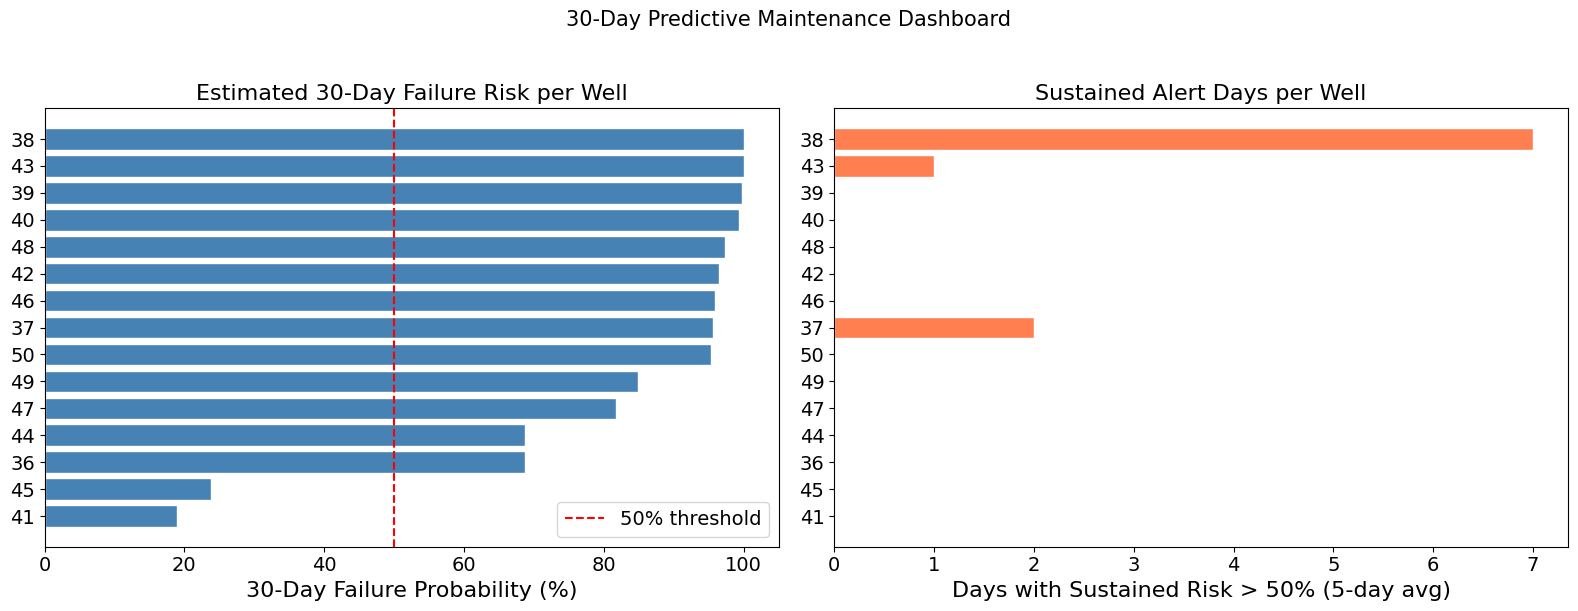

In [30]:
top_wells = resumen_test.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_wells.index.astype(str), top_wells['P_30_days(%)'],
             color='steelblue', edgecolor='white')
axes[0].axvline(x=50, color='red', linestyle='--', linewidth=1.5, label='50% threshold')
axes[0].set_xlabel('30-Day Failure Probability (%)')
axes[0].set_title('Estimated 30-Day Failure Risk per Well')
axes[0].invert_yaxis()
axes[0].legend()

axes[1].barh(top_wells.index.astype(str), top_wells['sustained_alert_days'],
             color='coral', edgecolor='white')
axes[1].set_xlabel('Days with Sustained Risk > 50% (5-day avg)')
axes[1].set_title('Sustained Alert Days per Well')
axes[1].invert_yaxis()

plt.suptitle('30-Day Predictive Maintenance Dashboard', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

##  Risk Tier Classification

Each well is assigned to one of four risk tiers based on its 30-day probability and sustained alert days:

| Tier | Condition |
|---|---|
| **CRITICAL** | P₃₀ ≥ 75 % OR sustained alert days ≥ 10 |
| **HIGH** | P₃₀ ≥ 40 % OR sustained alert days ≥ 5 |
| **MEDIUM** | P₃₀ ≥ 15 % |
| **LOW** | Otherwise |

In [31]:
def classify_risk(row):
    if row['P_30_days(%)'] >= 75 or row['sustained_alert_days'] >= 10:
        return 'CRITICAL'
    elif row['P_30_days(%)'] >= 40 or row['sustained_alert_days'] >= 5:
        return 'HIGH'
    elif row['P_30_days(%)'] >= 15:
        return 'MEDIUM'
    else:
        return 'LOW'

resumen_test['RISK_TIER'] = resumen_test.apply(classify_risk, axis=1)

print("── Well Risk Tiers ─────────────────────────────────────────────")
print(resumen_test['RISK_TIER'].value_counts())
print()
print(resumen_test[['P_30_days(%)', 'sustained_alert_days', 'RISK_TIER']]
      .sort_values('P_30_days(%)', ascending=False)
      .to_string())

── Well Risk Tiers ─────────────────────────────────────────────
RISK_TIER
CRITICAL    11
HIGH         2
MEDIUM       2
Name: count, dtype: int64

         P_30_days(%)  sustained_alert_days RISK_TIER
WELL_ID                                              
38              100.0                     7  CRITICAL
43              100.0                     1  CRITICAL
39               99.8                     0  CRITICAL
40               99.3                     0  CRITICAL
48               97.4                     0  CRITICAL
42               96.5                     0  CRITICAL
46               95.9                     0  CRITICAL
37               95.6                     2  CRITICAL
50               95.3                     0  CRITICAL
49               84.9                     0  CRITICAL
47               81.7                     0  CRITICAL
44               68.7                     0      HIGH
36               68.7                     0      HIGH
45               23.8                     0